In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
np.set_printoptions(suppress=True)

In [5]:
sns.set_theme(style="whitegrid")

In [7]:
df=sns.load_dataset("tips")

In [8]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [10]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


<b>Measure of Central Tendency

In [12]:
print(df.columns)

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')


In [13]:
col=df["total_bill"]
print(type(col))
col

<class 'pandas.Series'>


0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64

In [15]:
mean_val=col.mean()
print("mean  vlaue",mean_val)

mean_w_np=np.mean(col)
print(mean_w_np)

median_w_np=np.median(col)
print(median_w_np)

mean  vlaue 19.78594262295082
19.78594262295082
17.795


In [17]:
mod_val=col.mode()[0]
print(mod_val)

13.42


In [18]:
arr=np.array([df["total_bill"]==13.42])

3<b>Distribution Curve

In [33]:
col=df["total_bill"]
mean_val=np.mean(col)
mean_w_np=np.mean(col)
median_val=np.median(col)




In [23]:
#visulazing the histogram 

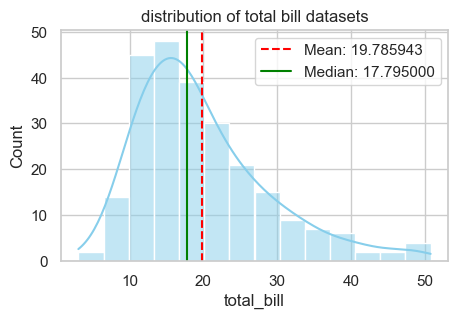

In [34]:
plt.figure(figsize=(5,3))
sns.histplot(col,kde=True,color="skyblue")
plt.axvline(mean_val,color="red",linestyle="--",label=f"Mean: {mean_val:2f}",)
plt.axvline(median_val,color="green",linestyle="-",label=f"Median: {median_val:2f}",)
plt.legend()
plt.title("distribution of total bill datasets")
plt.show()

4.<b>Measure of Spread

In [40]:
#range
data_range=col.max()-col.min()

#variance
variance=np.var(col)
#std deviation
std_dev=np.std(col)
#inter quartile range
q1=np.percentile(col,25)
q3=np.percentile(col,75)
iqr=q3-q1


print(f"range:{data_range:.2f}")
print(f"variance:{variance:.2f}")
print(f"standard_deviation:{std_dev:.2f}")
print(f"IQR:{iqr:.2f}")





range:47.74
variance:78.93
standard_deviation:8.88
IQR:10.78


<b>5.summmary statisticss 

In [42]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


<b>1.Descriptive statistics<br>
<b>2.Predictive statistics<br>
<b>3.Presciptive statistics

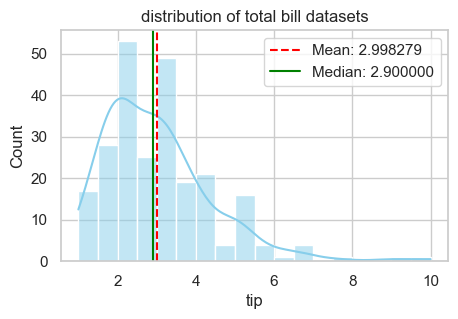

In [43]:
col=df["tip"]
mean_val=np.mean(col)
mean_w_np=np.mean(col)
median_val=np.median(col)
plt.figure(figsize=(5,3))
sns.histplot(col,kde=True,color="skyblue")
plt.axvline(mean_val,color="red",linestyle="--",label=f"Mean: {mean_val:2f}",)
plt.axvline(median_val,color="green",linestyle="-",label=f"Median: {median_val:2f}",)
plt.legend()
plt.title("distribution of total bill datasets")
plt.show()


<b>6.Data Distribution and skewness

In [44]:
print(df["tip"].skew())
print(df["total_bill"].skew())

1.4654510370979401
1.1332130376158205


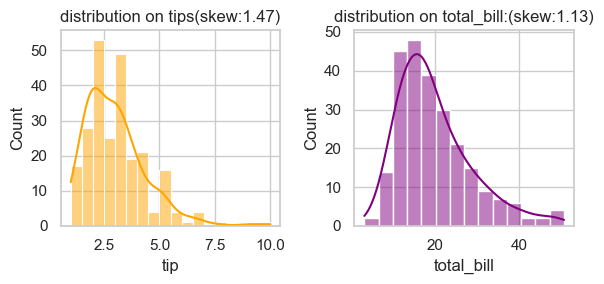

In [49]:
plt.figure(figsize=(6,3))
#plot 1: tip distribution

plt.subplot(1,2,1)
sns.histplot(df["tip"],kde=True,color="orange")
plt.title(f"distribution on tips(skew:{df["tip"].skew():.2f})")


plt.subplot(1,2,2)
sns.histplot(df["total_bill"],kde=True,color="purple")
plt.title(f"distribution on total_bill:(skew:{df["total_bill"].skew():.2f})")

plt.tight_layout()
plt.show()


<b>7.Outlier Detection

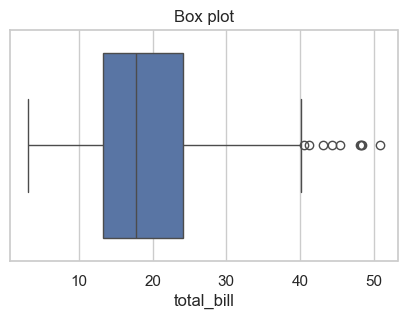

In [50]:
#1.Visual method
plt.figure(figsize=(5,3))
sns.boxplot(x=df["total_bill"])
plt.title("Box plot")
plt.show()

In [55]:
Q1=df["total_bill"].quantile(0.25)
Q3=df["total_bill"].quantile(0.75)
IQR=Q3 -Q1
 
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR


print(lower_bound)
print(upper_bound)
#FILTER OUTLIER

outlier=df[(df["total_bill"]<lower_bound) | (df["total_bill"]>upper_bound)]
print(len(outlier))



-2.8224999999999945
40.29749999999999
9


<b>8.Correlation Matrix

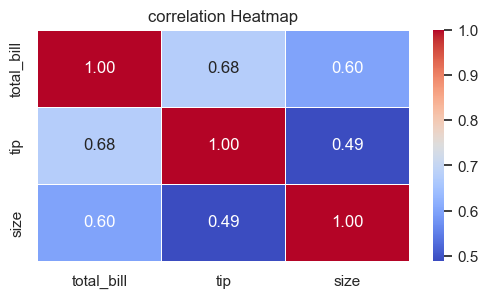

In [56]:
#calculate correlatin matrix
numerical_df=df.select_dtypes(include=[np.number])
corr_matrix=numerical_df.corr()

#visulaize with heatmap
plt.figure(figsize=(6,3))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",linewidth=0.5,fmt=".2f")
plt.title("correlation Heatmap")
plt.show()